<a href="https://colab.research.google.com/github/Abhisek963/machineLearning_Lab/blob/main/02April01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [36]:
df=pd.read_csv('new.csv')
target_col='Response'

In [37]:
df.drop(columns=['ID'], inplace=True, errors='ignore')
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')
df['TenureDays'] = (pd.Timestamp.today() - df['Dt_Customer']).dt.days
df.drop(columns=['Dt_Customer'], inplace=True)
df['Age'] = datetime.now().year - df['Year_Birth']
df['TotalSpend'] = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['TotalBuys'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

In [38]:
df['Income']=df['Income'].fillna(df['Income'].median())
df.dropna(inplace=True)

In [39]:
X=df.drop(target_col, axis=1)
y=df[target_col]

In [40]:
num_cols=X.select_dtypes(include=['int64','float64']).columns
cat_cols=X.select_dtypes(include=['object']).columns

In [41]:
preprocessor = ColumnTransformer([('num', 'passthrough', num_cols),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)])

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [43]:
over = SMOTE(sampling_strategy=0.5, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.8, random_state=42)

In [46]:
dt=DecisionTreeClassifier(random_state=42)
param_grid = {
    'model__max_depth': [5, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__criterion': ['gini', 'entropy']
}

In [47]:
pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('over', over),
    ('under', under),
    ('model', dt)
])

In [48]:
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
print("Best Params:", grid.best_params_)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Accuracy: 0.8641304347826086

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92       157
           1       0.53      0.67      0.59        27

    accuracy                           0.86       184
   macro avg       0.73      0.78      0.75       184
weighted avg       0.88      0.86      0.87       184



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


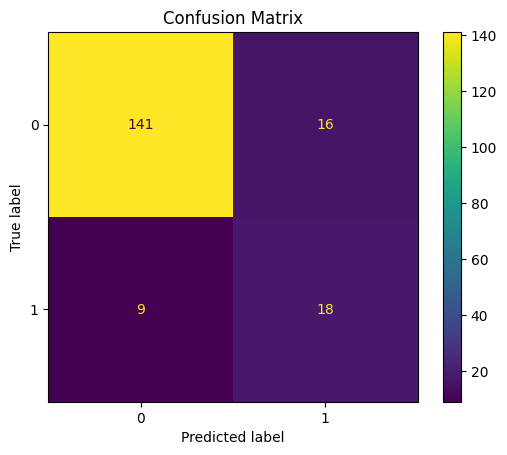

In [49]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [51]:
y_prob=grid.predict_proba(X_test)[:, 1]
fpr, tpr, _=roc_curve(y_test, y_prob)
roc_auc=auc(fpr, tpr)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


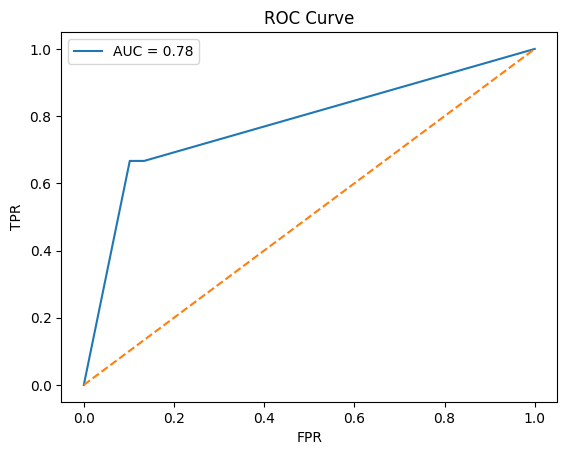

In [52]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()